In [ ]:
mat = scipy.io.loadmat("AD.mat")
print(mat.keys())

data = mat['AD']
print(data.shape)

first_participant = data[0,12]
epoch = first_participant['epoch']
odor = first_participant['odor']
noisy = first_participant['noisy']
print(epoch.shape)
print(odor.shape)
print(noisy.shape)

dict_keys(['__header__', '__version__', '__globals__', 'AD'])
(1, 13)
(4, 600, 120)
(120, 1)
(1, 8)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import pandas as pd
import os
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

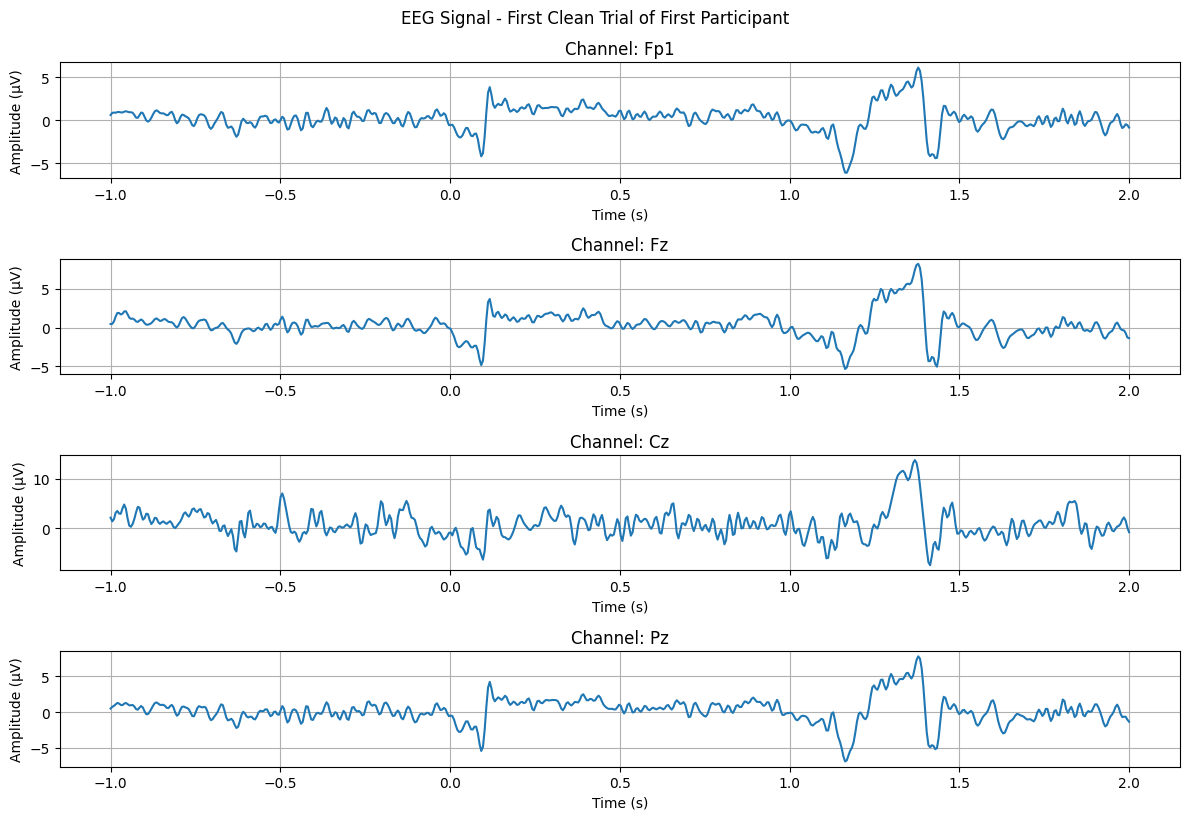

In [ ]:
fs = 200  # Sampling rate
t = np.linspace(-1, 2, 600)  # From -1s to +2s

# Channel labels
channels = ['Fp1', 'Fz', 'Cz', 'Pz']

# Remove noisy trials
all_trials = np.arange(epoch.shape[2])
clean_trials = np.setdiff1d(all_trials, noisy)

# Choose first clean trial
trial_index = clean_trials[0]

# Plot
plt.figure(figsize=(12, 8))
for ch in range(4):
    plt.subplot(4, 1, ch + 1)
    plt.plot(t, epoch[ch, :, trial_index])
    plt.title(f'Channel: {channels[ch]}')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (µV)')
    plt.grid(True)

plt.tight_layout()
plt.suptitle('EEG Signal - First Clean Trial of First Participant', y=1.02)
plt.show()

In [ ]:
import numpy as np
import scipy.io

# ==============================
# Parameters
# ==============================
FS = 200                 # Sampling frequency
N_FFT_FEATURES = 30      # Number of FFT bins per channel

# ==============================
# Load MAT file
# ==============================
mat = scipy.io.loadmat("AD.mat")
data = mat['AD']         # shape: (1, 13)

num_subjects = data.shape[1]
print("Number of subjects:", num_subjects)

all_subject_features = []

# ==============================
# Loop through subjects
# ==============================
for subj in range(num_subjects):

    subject = data[0, subj]

    epoch = subject['epoch']    # (4, 600, trials)
    noisy = subject['noisy'].flatten() - 1  # MATLAB → Python index

    n_channels, n_samples, n_trials = epoch.shape

    # --------------------------
    # Remove noisy trials
    # --------------------------
    all_trials = np.arange(n_trials)
    clean_trials = np.setdiff1d(all_trials, noisy)

    clean_epoch = epoch[:, :, clean_trials]

    # --------------------------
    # FFT feature extraction
    # --------------------------
    subject_features = []

    for ch in range(n_channels):

        ch_data = clean_epoch[ch, :, :]   # (600, clean_trials)

        fft_trials = []

        for tr in range(ch_data.shape[1]):
            signal = ch_data[:, tr]

            fft_vals = np.abs(np.fft.rfft(signal))
            fft_vals = fft_vals[:N_FFT_FEATURES]   # keep low frequencies

            fft_trials.append(fft_vals)

        fft_trials = np.array(fft_trials)

        # Average across trials
        ch_feature = np.mean(fft_trials, axis=0)

        subject_features.extend(ch_feature)

    all_subject_features.append(subject_features)

# ==============================
# Final feature matrix
# ==============================
X_AD = np.array(all_subject_features)

print("AD feature matrix shape:", X_AD.shape)


Number of subjects: 13
AD feature matrix shape: (13, 120)


In [ ]:
import numpy as np
import scipy.io

# ==============================
# Parameters
# ==============================
FS = 200
N_FFT_FEATURES = 30

# ==============================
# Feature extraction function
# ==============================
def extract_fft_features(mat_file):

    mat = scipy.io.loadmat(mat_file)
    data = mat[list(mat.keys())[-1]]   # AD / MCI / CT

    features = []

    for subj in range(data.shape[1]):

        subject = data[0, subj]
        epoch = subject['epoch']
        noisy = subject['noisy'].flatten() - 1

        n_channels, n_samples, n_trials = epoch.shape

        clean_trials = np.setdiff1d(np.arange(n_trials), noisy)
        clean_epoch = epoch[:, :, clean_trials]

        subject_features = []

        for ch in range(n_channels):

            fft_trials = []

            for tr in range(clean_epoch.shape[2]):
                signal = clean_epoch[ch, :, tr]
                fft_vals = np.abs(np.fft.rfft(signal))
                fft_vals = fft_vals[:N_FFT_FEATURES]
                fft_trials.append(fft_vals)

            fft_trials = np.array(fft_trials)
            subject_features.extend(np.mean(fft_trials, axis=0))

        features.append(subject_features)

    return np.array(features)


# ==============================
# Extract features
# ==============================
X_AD  = extract_fft_features("AD.mat")
X_MCI = extract_fft_features("MCI.mat")
X_CT  = extract_fft_features("normal.mat")

# ==============================
# Labels
# ==============================
y_AD  = np.zeros(X_AD.shape[0])
y_MCI = np.ones(X_MCI.shape[0])
y_CT  = np.ones(X_CT.shape[0]) * 2

# ==============================
# Combine dataset
# ==============================
X = np.vstack((X_AD, X_MCI, X_CT))
y = np.concatenate((y_AD, y_MCI, y_CT))

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)
print("Class distribution:", np.bincount(y.astype(int)))


Final X shape: (35, 120)
Final y shape: (35,)
Class distribution: [13  7 15]


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features normalized")


Features normalized


/tmp/ipython-input-370360331.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  band_powers.append(np.trapz(Pxx[idx], f[idx]))


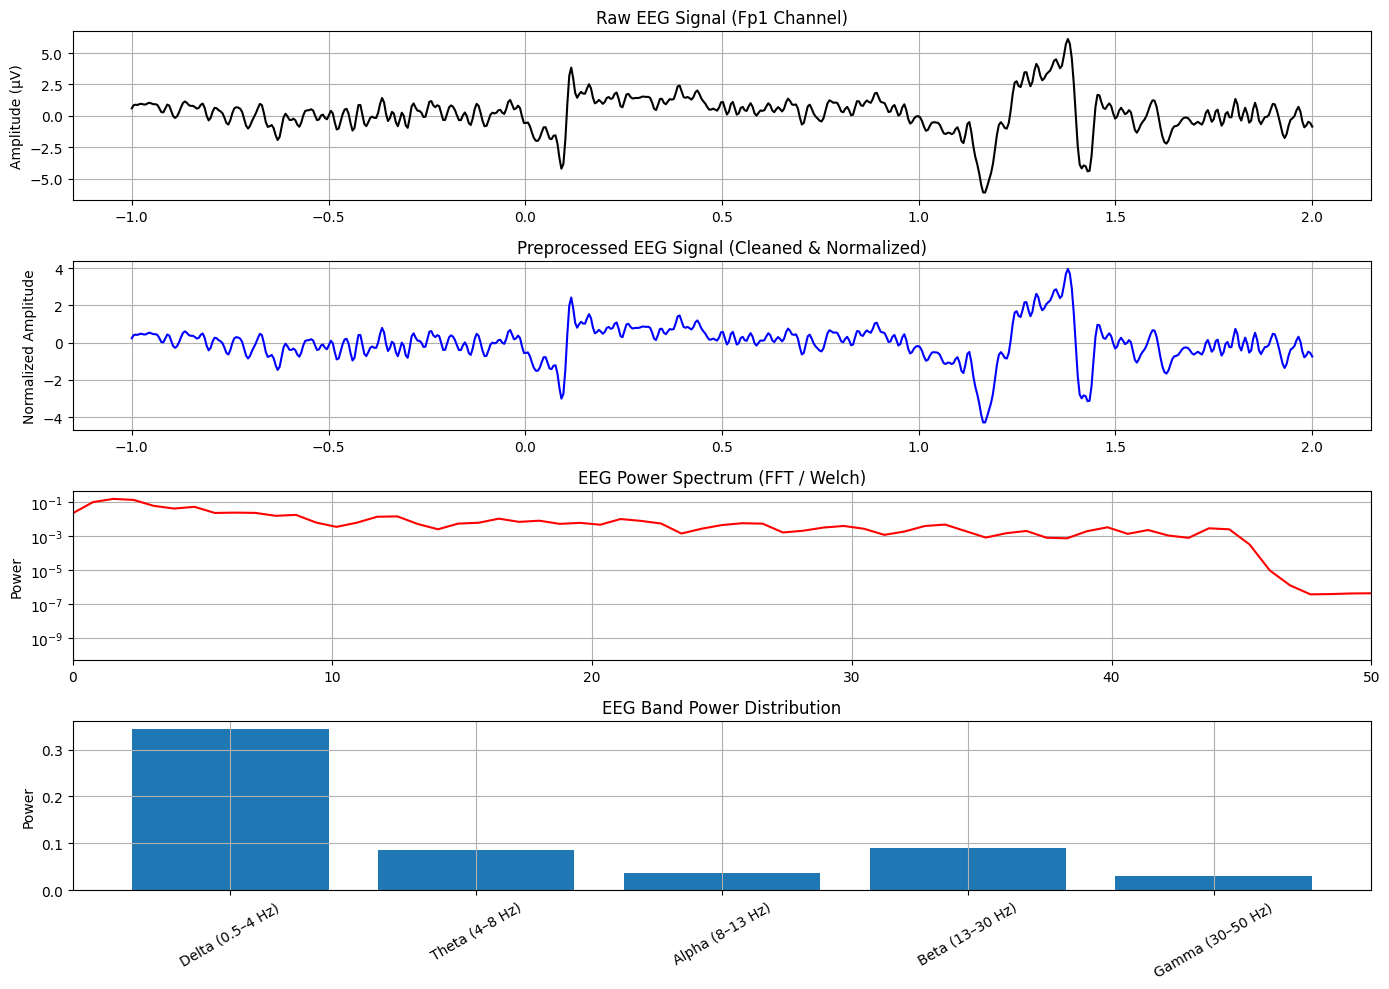

In [ ]:
# ================= EEG VISUALIZATION PIPELINE =================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.stats import zscore

# -------- Select one EEG sample --------
ch = 0            # channel index (Fp1)
trial = 0         # trial index
signal_raw = epoch[ch, :, trial]

t = np.linspace(-1, 2, signal_raw.shape[0])

# -------- Preprocessing --------
signal_clean = signal_raw.copy()
signal_clean[~np.isfinite(signal_clean)] = 0   # remove NaN/Inf
signal_clean = signal_clean - np.mean(signal_clean)  # DC removal
signal_clean = zscore(signal_clean)             # normalization

# -------- FFT / PSD --------
f, Pxx = welch(signal_clean, fs, nperseg=256)

# -------- Band power --------
bands = {
    'Delta (0.5–4 Hz)': (0.5, 4),
    'Theta (4–8 Hz)': (4, 8),
    'Alpha (8–13 Hz)': (8, 13),
    'Beta (13–30 Hz)': (13, 30),
    'Gamma (30–50 Hz)': (30, 50)
}

band_powers = []
for band in bands.values():
    idx = np.logical_and(f >= band[0], f <= band[1])
    band_powers.append(np.trapz(Pxx[idx], f[idx]))

# ===================== PLOTS =====================

plt.figure(figsize=(14, 10))

# 1️⃣ Raw EEG
plt.subplot(4,1,1)
plt.plot(t, signal_raw, color='black')
plt.title("Raw EEG Signal (Fp1 Channel)")
plt.ylabel("Amplitude (µV)")
plt.grid(True)

# 2️⃣ Preprocessed EEG
plt.subplot(4,1,2)
plt.plot(t, signal_clean, color='blue')
plt.title("Preprocessed EEG Signal (Cleaned & Normalized)")
plt.ylabel("Normalized Amplitude")
plt.grid(True)

# 3️⃣ FFT / Power Spectrum
plt.subplot(4,1,3)
plt.semilogy(f, Pxx, color='red')
plt.xlim(0, 50)
plt.title("EEG Power Spectrum (FFT / Welch)")
plt.ylabel("Power")
plt.grid(True)

# 4️⃣ Band Power
plt.subplot(4,1,4)
plt.bar(bands.keys(), band_powers)
plt.title("EEG Band Power Distribution")
plt.ylabel("Power")
plt.xticks(rotation=30)
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, confusion_matrix

# Select AD (0) and CT (2)
idx = np.where((y == 0) | (y == 2))[0]
X_bin = X_scaled[idx]
y_bin = y[idx]

# Convert labels: AD=0, CT=1
y_bin = (y_bin == 2).astype(int)

loo = LeaveOneOut()
clf = SVC(kernel='poly', degree=3, C=1)

y_true, y_pred = [], []

for train, test in loo.split(X_bin):
    clf.fit(X_bin[train], y_bin[train])
    y_pred.append(clf.predict(X_bin[test])[0])
    y_true.append(y_bin[test])

acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print("AD vs normal Accuracy:", acc)
print("Confusion Matrix:\n", cm)
TN, FP, FN, TP = cm.ravel()

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print("Sensitivity:", sensitivity)
print("Specificity:", specificity)



AD vs normal Accuracy: 0.5714285714285714
Confusion Matrix:
 [[ 1 12]
 [ 0 15]]
Sensitivity: 1.0
Specificity: 0.07692307692307693


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np

def run_binary_LOOCV(X, y, class_a, class_b, name):
    # select samples
    idx = np.where((y == class_a) | (y == class_b))[0]
    Xb = X[idx]
    yb = y[idx]

    # relabel: class_a=0, class_b=1
    yb = (yb == class_b).astype(int)

    loo = LeaveOneOut()
    clf = SVC(kernel='poly', degree=3, C=1)

    y_true, y_pred = [], []

    for train, test in loo.split(Xb):
        clf.fit(Xb[train], yb[train])
        y_pred.append(clf.predict(Xb[test])[0])
        y_true.append(yb[test])

    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    TN, FP, FN, TP = cm.ravel()
    sensitivity = TP / (TP + FN)
    specificity = TN / (TN + FP)

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Sensitivity:", sensitivity)
    print("Specificity:", specificity)
    print("Confusion Matrix:\n", cm)


In [ ]:
# MCI=1, normal=2
run_binary_LOOCV(X_scaled, y, class_a=1, class_b=2, name="MCI vs CT")



MCI vs CT
Accuracy: 0.4090909090909091
Sensitivity: 0.6
Specificity: 0.0
Confusion Matrix:
 [[0 7]
 [6 9]]


In [ ]:
# AD=0, MCI=1
run_binary_LOOCV(X_scaled, y, class_a=0, class_b=1, name="AD vs MCI")



AD vs MCI
Accuracy: 0.65
Sensitivity: 0.0
Specificity: 1.0
Confusion Matrix:
 [[13  0]
 [ 7  0]]


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np

def run_DT_LOOCV(X, y, class_a, class_b, name):
    # Select relevant classes
    idx = np.where((y == class_a) | (y == class_b))[0]
    Xb = X[idx]
    yb = y[idx]

    # Relabel classes → 0 and 1
    yb = (yb == class_b).astype(int)

    loo = LeaveOneOut()
    clf = DecisionTreeClassifier(
        criterion='entropy',   # C4.5-like
        max_depth=None,
        random_state=42
    )

    y_true, y_pred = [], []

    for train, test in loo.split(Xb):
        clf.fit(Xb[train], yb[train])
        y_pred.append(clf.predict(Xb[test])[0])
        y_true.append(yb[test])

    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    TN, FP, FN, TP = cm.ravel()
    sensitivity = TP / (TP + FN)
    specificity = TN / (TN + FP)

    print(f"\n{name} (Decision Tree)")
    print("Accuracy:", acc)
    print("Sensitivity:", sensitivity)
    print("Specificity:", specificity)
    print("Confusion Matrix:\n", cm)


In [ ]:
# AD=0, normal=2
run_DT_LOOCV(X_scaled, y, class_a=0, class_b=2, name="AD vs CT")



AD vs CT (Decision Tree)
Accuracy: 0.2857142857142857
Sensitivity: 0.4
Specificity: 0.15384615384615385
Confusion Matrix:
 [[ 2 11]
 [ 9  6]]


In [ ]:
# MCI=1, CT=2
run_DT_LOOCV(X_scaled, y, class_a=1, class_b=2, name="MCI vs CT")



MCI vs CT (Decision Tree)
Accuracy: 0.9090909090909091
Sensitivity: 0.8666666666666667
Specificity: 1.0
Confusion Matrix:
 [[ 7  0]
 [ 2 13]]


In [ ]:
# AD=0, MCI=1
run_DT_LOOCV(X_scaled, y, class_a=0, class_b=1, name="AD vs MCI")



AD vs MCI (Decision Tree)
Accuracy: 0.85
Sensitivity: 0.7142857142857143
Specificity: 0.9230769230769231
Confusion Matrix:
 [[12  1]
 [ 2  5]]


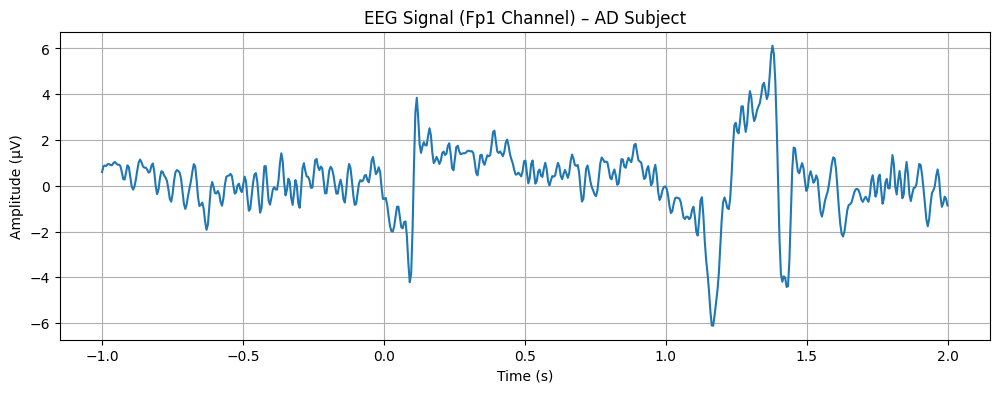

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(t, epoch[0,:,trial_index])
plt.title("EEG Signal (Fp1 Channel) – AD Subject")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.grid(True)
plt.show()


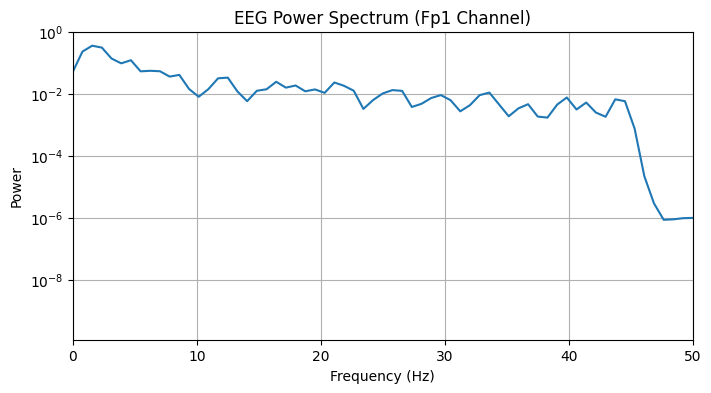

In [ ]:
from scipy.signal import welch

plt.figure(figsize=(8,4))
f, Pxx = welch(epoch[0,:,trial_index], fs, nperseg=256)
plt.semilogy(f, Pxx)
plt.xlim([0, 50])
plt.title("EEG Power Spectrum (Fp1 Channel)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.grid(True)
plt.show()


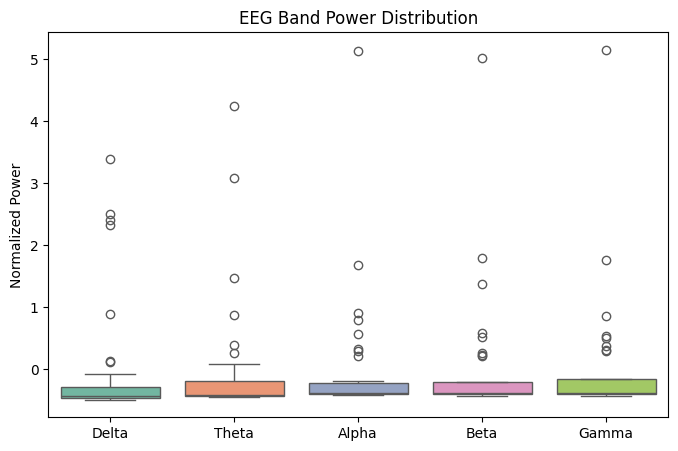

In [ ]:
import seaborn as sns

band_labels = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']

plt.figure(figsize=(8,5))
sns.boxplot(data=X_scaled[:, :5], palette='Set2')
plt.xticks(range(5), band_labels)
plt.ylabel("Normalized Power")
plt.title("EEG Band Power Distribution")
plt.show()


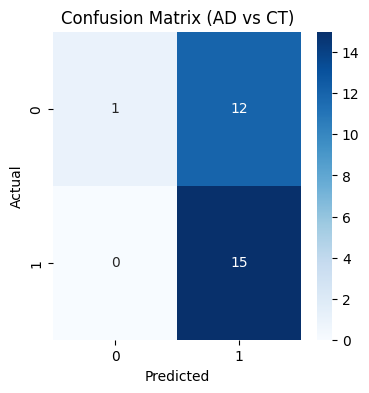

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (AD vs CT)")
plt.show()


Decision Tree Accuracy (AD vs CT): 0.2857142857142857
Decision Tree Confusion Matrix:
 [[ 2 11]
 [ 9  6]]
SVM Accuracy (AD vs CT): 0.5714285714285714


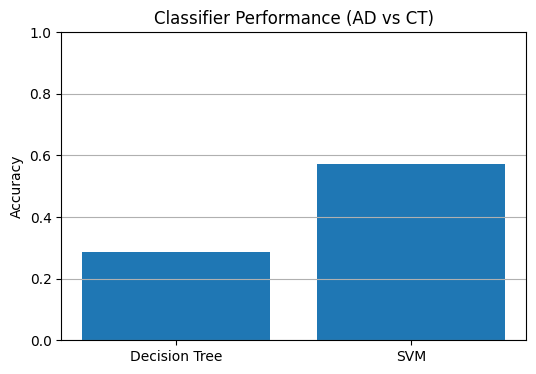

In [ ]:
# ================= SINGLE CELL: DT + SVM + GRAPH =================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, confusion_matrix

# -------- Decision Tree LOOCV --------
def DT_LOOCV(X, y, class_a, class_b):
    idx = np.where((y == class_a) | (y == class_b))[0]
    Xb = X[idx]
    yb = y[idx]
    yb = (yb == class_b).astype(int)

    loo = LeaveOneOut()
    clf = DecisionTreeClassifier(criterion='entropy', random_state=42)

    y_true, y_pred = [], []
    for train, test in loo.split(Xb):
        clf.fit(Xb[train], yb[train])
        y_pred.append(clf.predict(Xb[test])[0])
        y_true.append(yb[test])

    return accuracy_score(y_true, y_pred), confusion_matrix(y_true, y_pred)

# -------- SVM LOOCV --------
def SVM_LOOCV(X, y, class_a, class_b):
    idx = np.where((y == class_a) | (y == class_b))[0]
    Xb = X[idx]
    yb = y[idx]
    yb = (yb == class_b).astype(int)

    loo = LeaveOneOut()
    clf = SVC(kernel='poly', degree=3, C=1)

    y_true, y_pred = [], []
    for train, test in loo.split(Xb):
        clf.fit(Xb[train], yb[train])
        y_pred.append(clf.predict(Xb[test])[0])
        y_true.append(yb[test])

    return accuracy_score(y_true, y_pred)

# -------- RUN (AD vs CT) --------
dt_acc, dt_cm = DT_LOOCV(X_scaled, y, class_a=0, class_b=2)
svm_acc = SVM_LOOCV(X_scaled, y, class_a=0, class_b=2)

print("Decision Tree Accuracy (AD vs CT):", dt_acc)
print("Decision Tree Confusion Matrix:\n", dt_cm)
print("SVM Accuracy (AD vs CT):", svm_acc)

# -------- BAR GRAPH --------
models = ['Decision Tree', 'SVM']
accuracies = [dt_acc, svm_acc]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Classifier Performance (AD vs CT)")
plt.ylim([0,1])
plt.grid(axis='y')
plt.show()


In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

clf_tree = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,        # keep tree readable
    random_state=42
)

clf_tree.fit(X_scaled, y)


DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

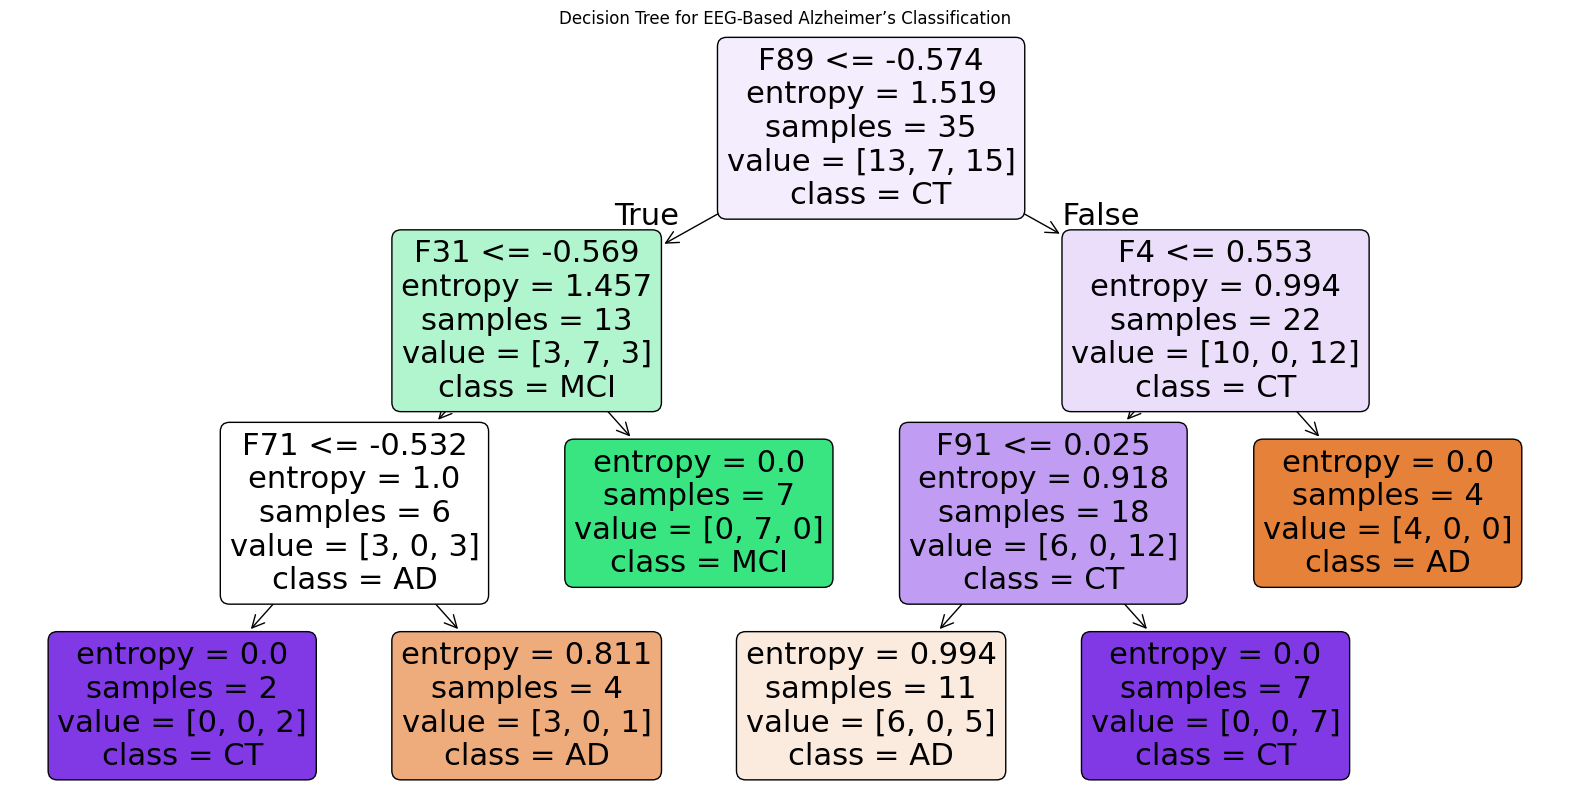

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(
    clf_tree,
    feature_names=[f'F{i+1}' for i in range(X.shape[1])],
    class_names=['AD', 'MCI', 'CT'],
    filled=True,
    rounded=True
)
plt.title("Decision Tree for EEG-Based Alzheimer’s Classification")
plt.show()
